In [1]:
import numpy as np
import pandas as pd

from itertools import combinations

rng = np.random.default_rng(42)

df_sampling = pd.DataFrame(
    {
        "user_id": np.arange(1, 101),
        "category": rng.choice(["A", "B", "C"], size=100, p=[0.5, 0.3, 0.2]),
        "score": rng.normal(loc=75, scale=10, size=100).round(2),
    }
)

In [2]:
print(f'The shape of the Dataframe: {df_sampling.shape}' )
print(f'The columns of the Dataframe: {df_sampling.columns}' )
df_sampling.head()

The shape of the Dataframe: (100, 3)
The columns of the Dataframe: Index(['user_id', 'category', 'score'], dtype='str')


,user_id,category,score
0,1,B,79.00
1,2,A,65.95
2,3,C,71.22
3,4,B,87.99
4,5,A,71.44


In [3]:
df_sampling['score'].describe()[['mean', 'std', 'min', 'max']]

mean     74.859800
std       9.843752
min      53.680000
max     104.140000
Name: score, dtype: float64

In [4]:
df_sampling['category'].value_counts().sort_index()

category
A    53
B    33
C    14
Name: count, dtype: int64

In [5]:
df_sampling.groupby('category')['score'].describe()[['mean', 'std', 'min', 'max']]

,mean,std,min,max
category,,,,
A,74.200000,8.973076,60.29,94.97
B,76.272424,10.014058,58.25,96.28
C,74.027857,12.705514,53.68,104.14


In [10]:
random_sample = df_sampling.sample(n=20, random_state=42)
random_sample.shape

(20, 3)

In [11]:
random_sample.groupby('category')['score'].describe()[['mean', 'std', 'min', 'max']]

,mean,std,min,max
category,,,,
A,71.211250,8.747513,61.23,83.40
B,75.071429,6.553916,64.64,83.38
C,67.838000,10.015841,53.68,77.68


In [12]:
random_sample['category'].value_counts().sort_index()

category
A    8
B    7
C    5
Name: count, dtype: int64

## Stratified Sampling | proportional to the category distribution

In [19]:
stratified_sample = (
    df_sampling
    .groupby("category", group_keys=False)
    .sample(frac=0.2, random_state=42)
    .reset_index(drop=True)
)

In [22]:
stratified_sample['category'].value_counts().sort_index()

category
A    11
B     7
C     3
Name: count, dtype: int64

In [23]:
stratified_sample.head()

,user_id,category,score
0,39,A,78.14
1,84,A,77.19
2,93,A,92.24
3,29,A,89.63
4,86,A,86.06


In [24]:
# Summary statistics of the score column for the stratified sample:
stratified_sample.groupby('category')['score'].describe()[['mean', 'std', 'min', 'max']]

,mean,std,min,max
category,,,,
A,76.688182,10.510287,60.29,92.24
B,78.715714,10.081969,66.79,92.68
C,63.650000,5.447054,57.73,68.45


In [25]:
stratified_sample['category'].value_counts().sort_index()

category
A    11
B     7
C     3
Name: count, dtype: int64

In [26]:
df_sampling['category'].value_counts(normalize=True).sort_index()

category
A    0.53
B    0.33
C    0.14
Name: proportion, dtype: float64

In [27]:
stratified_sample['category'].value_counts(normalize=True).sort_index()

category
A    0.523810
B    0.333333
C    0.142857
Name: proportion, dtype: float64

## Stratified Sampling | Equal number of samples from each category

In [28]:
stratified_sample = (
    df_sampling
    .groupby("category", group_keys=False)
    .sample(n=10, random_state=42)
    .reset_index(drop=True)
)

### Splitting the data into control and treatment groups

#### Pure Random Splitting
- Completely random
- Does NOT preserve category distribution
- Can introduce bias

In [29]:
rng = np.random.default_rng(42)

df_random_split = df_sampling.assign(
    group=rng.choice(["control", "treatment"], size=len(df_sampling))
)

In [30]:
df_random_split['group'].value_counts()

group
treatment    52
control      48
Name: count, dtype: int64

#### Stratified Splitting

In [31]:
df_stratified_split = (
    df_sampling
    .assign(
        group=lambda x: (
            x.groupby("category")["user_id"]
            .transform(
                lambda g: rng.permutation(
                    ["control"] * (len(g)//2) + 
                    ["treatment"] * (len(g) - len(g)//2)
                )
            )
        )
    )
)

In [32]:
df_stratified_split[['group', 'category']].value_counts()

group      category
treatment  A           27
control    A           26
treatment  B           17
control    B           16
treatment  C            7
control    C            7
Name: count, dtype: int64

## Analyzing the results | Step 4

### Power Analysis With Python

In [33]:
import numpy as np
import pandas as pd
import math
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_ind
import scipy
import matplotlib.pyplot as plt

In [ ]:
# Calculating sample size
N = TTestIndPower().solve_power(effect_size = 0.4, power = 0.8, alpha = 0.05)

N

99.08032514676708

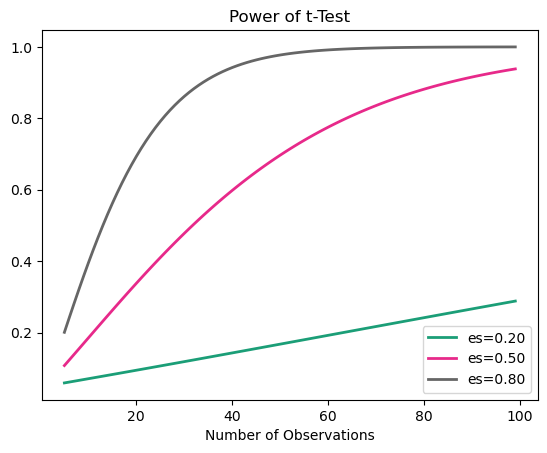

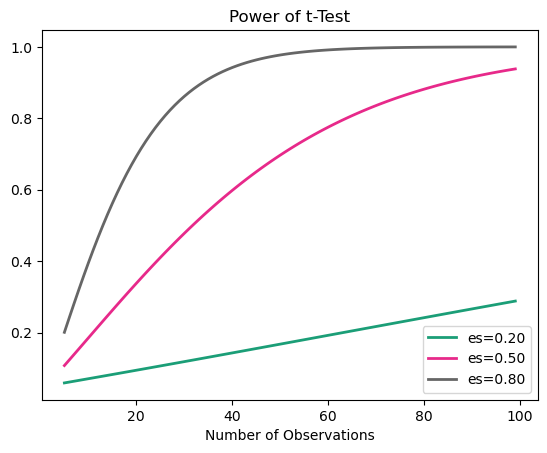

In [35]:
TTestIndPower().plot_power(dep_var='nobs', 
                            nobs=np.array(range(5, 100)), 
                            effect_size=np.array([0.2, 0.5, 0.8]),
                            title='Power of t-Test')